#  Heart Disease Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load dataset 
values = pd.read_csv("values.csv")
labels = pd.read_csv("labels.csv")

In [3]:
# merge the datasets 
df = values.merge(labels, on ="patient_id")

In [4]:
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [5]:
# data shape 
df.shape

(180, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [7]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [8]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]


Series([], dtype: int64)

In [9]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


# EDA

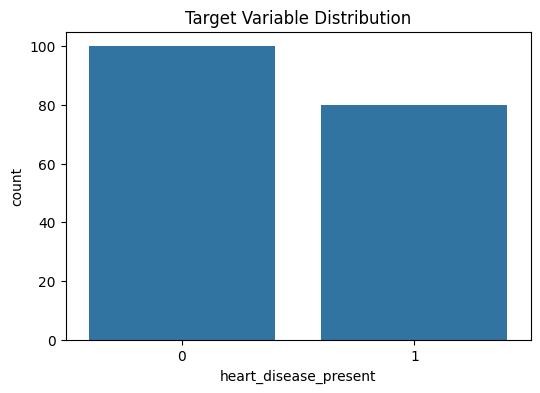

In [10]:
#Target Variable Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="heart_disease_present",data=df)
plt.title("Target Variable Distribution")
plt.show()

# Insight:
- The target variable distribution helps identify whether the dataset
- is balanced or imbalanced. Balanced datasets generally improve model learning.

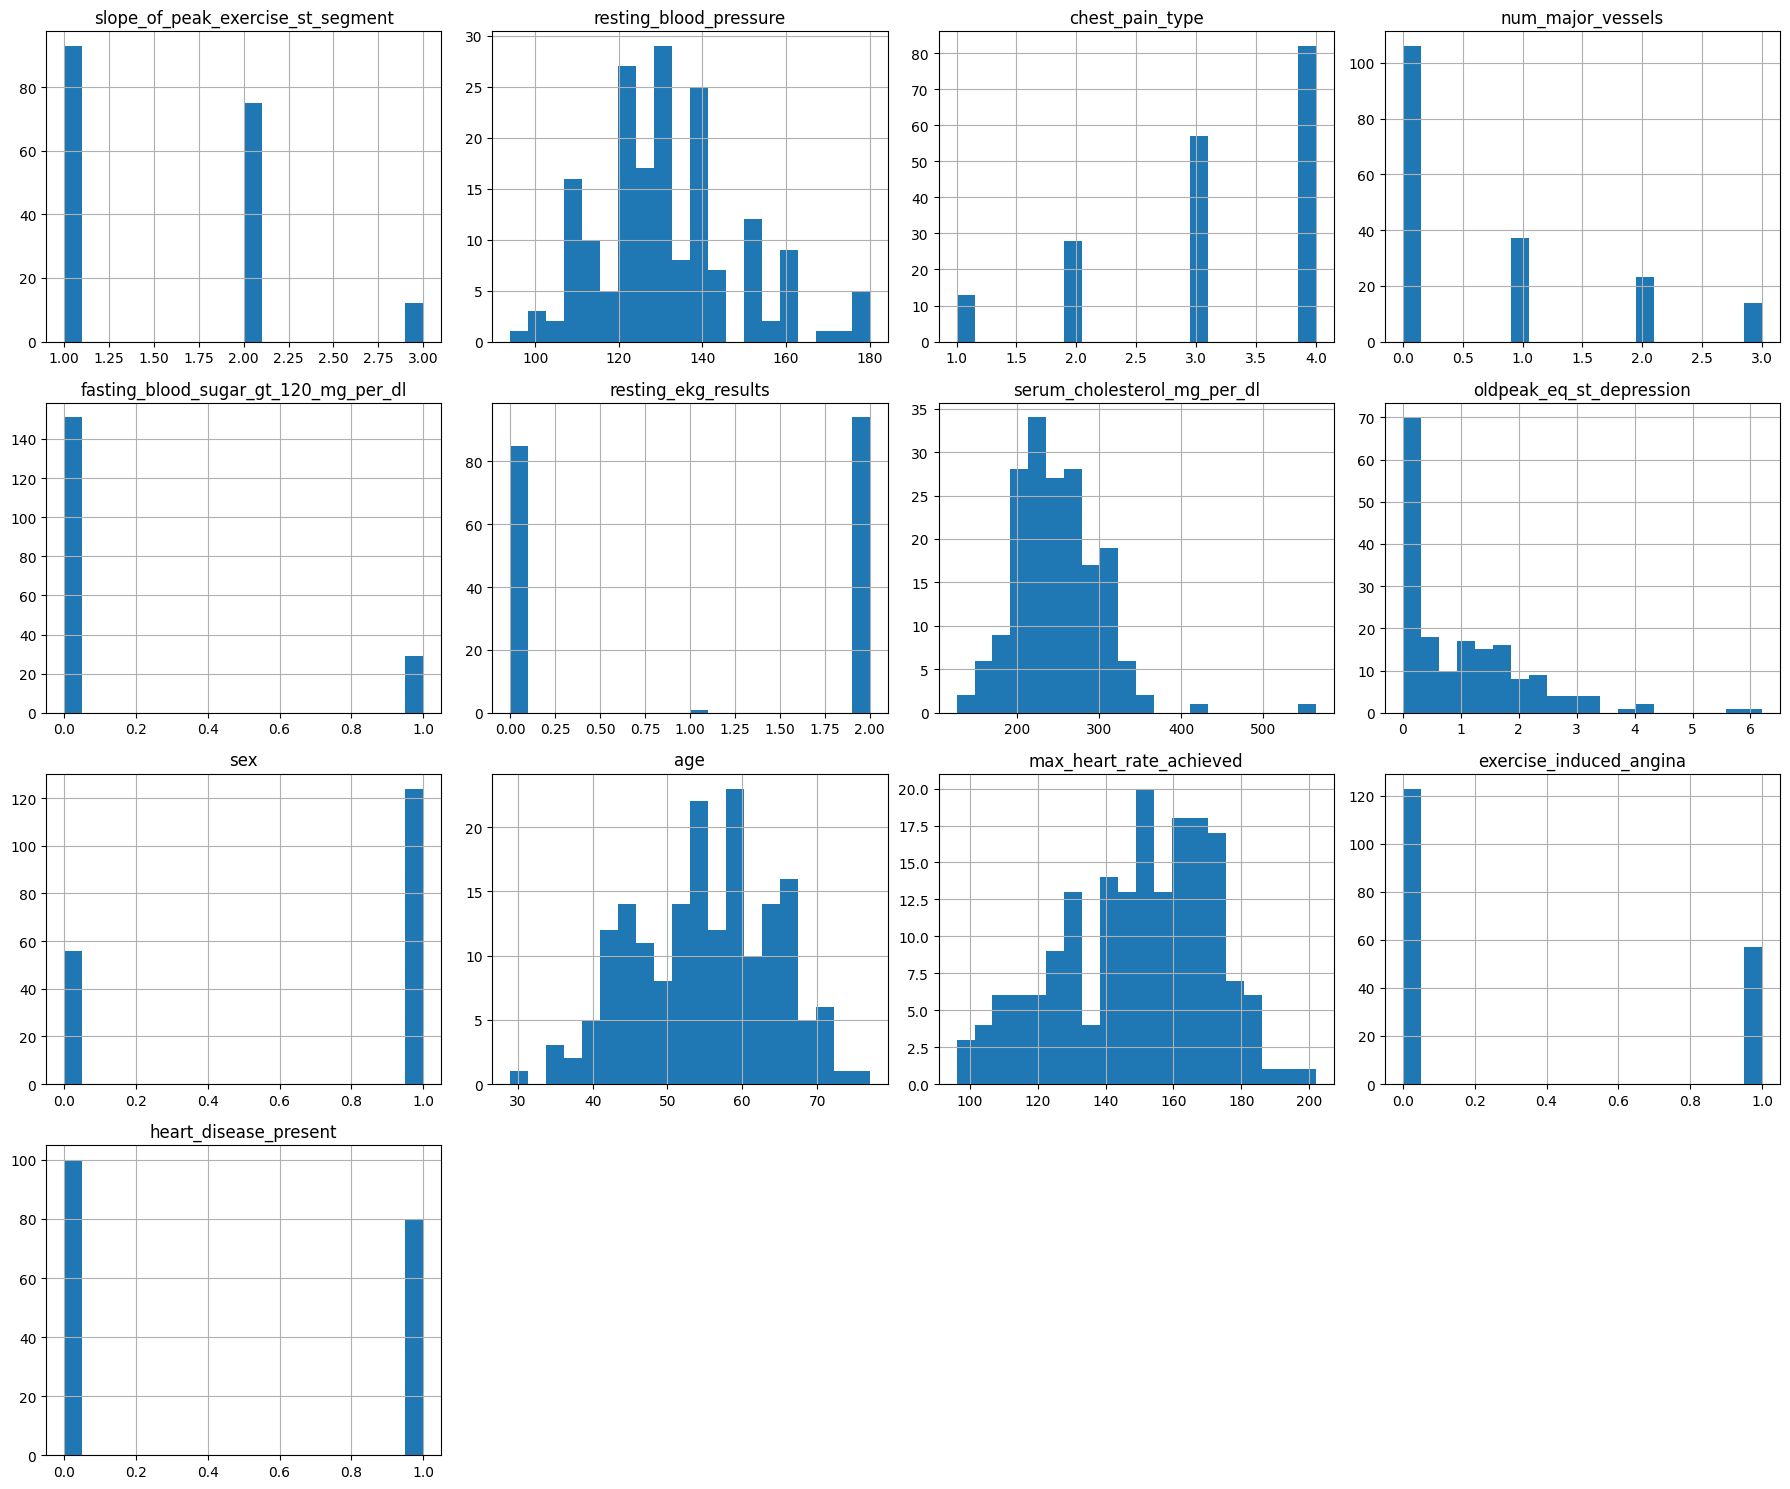

In [11]:
# Numerical Features Distribution
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].hist(figsize=(18,15),bins=20)
plt.tight_layout()
plt.show()

# Insight:
- Histograms help identify skewness, spread, and distribution patterns.
- Features with strong skewness may require transformation.

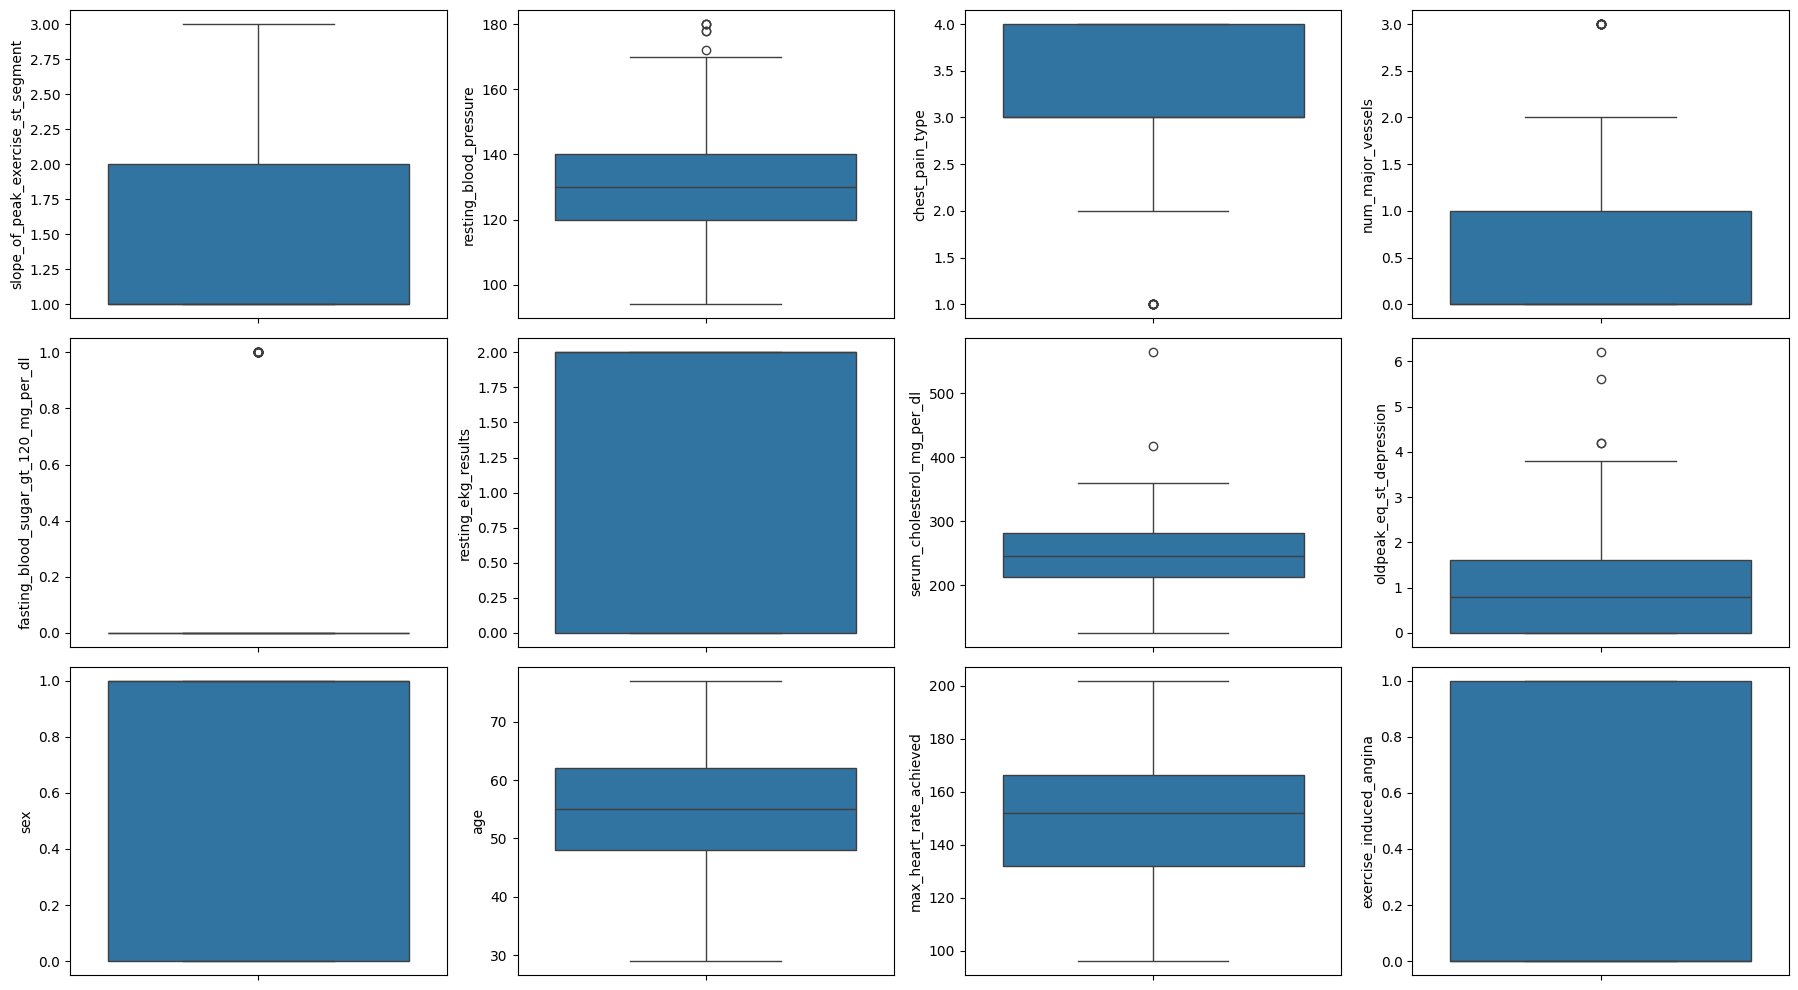

In [12]:
# Boxplots for Outlier Detection
plt.figure(figsize=(18,10))
for i ,col in enumerate(num_cols[:12]):
    plt.subplot(3,4,i+1)
    sns.boxplot(y=df[col])
plt.tight_layout()
plt.show()

# Insight:
- Boxplots help detect extreme values and outliers that may affect model performance.

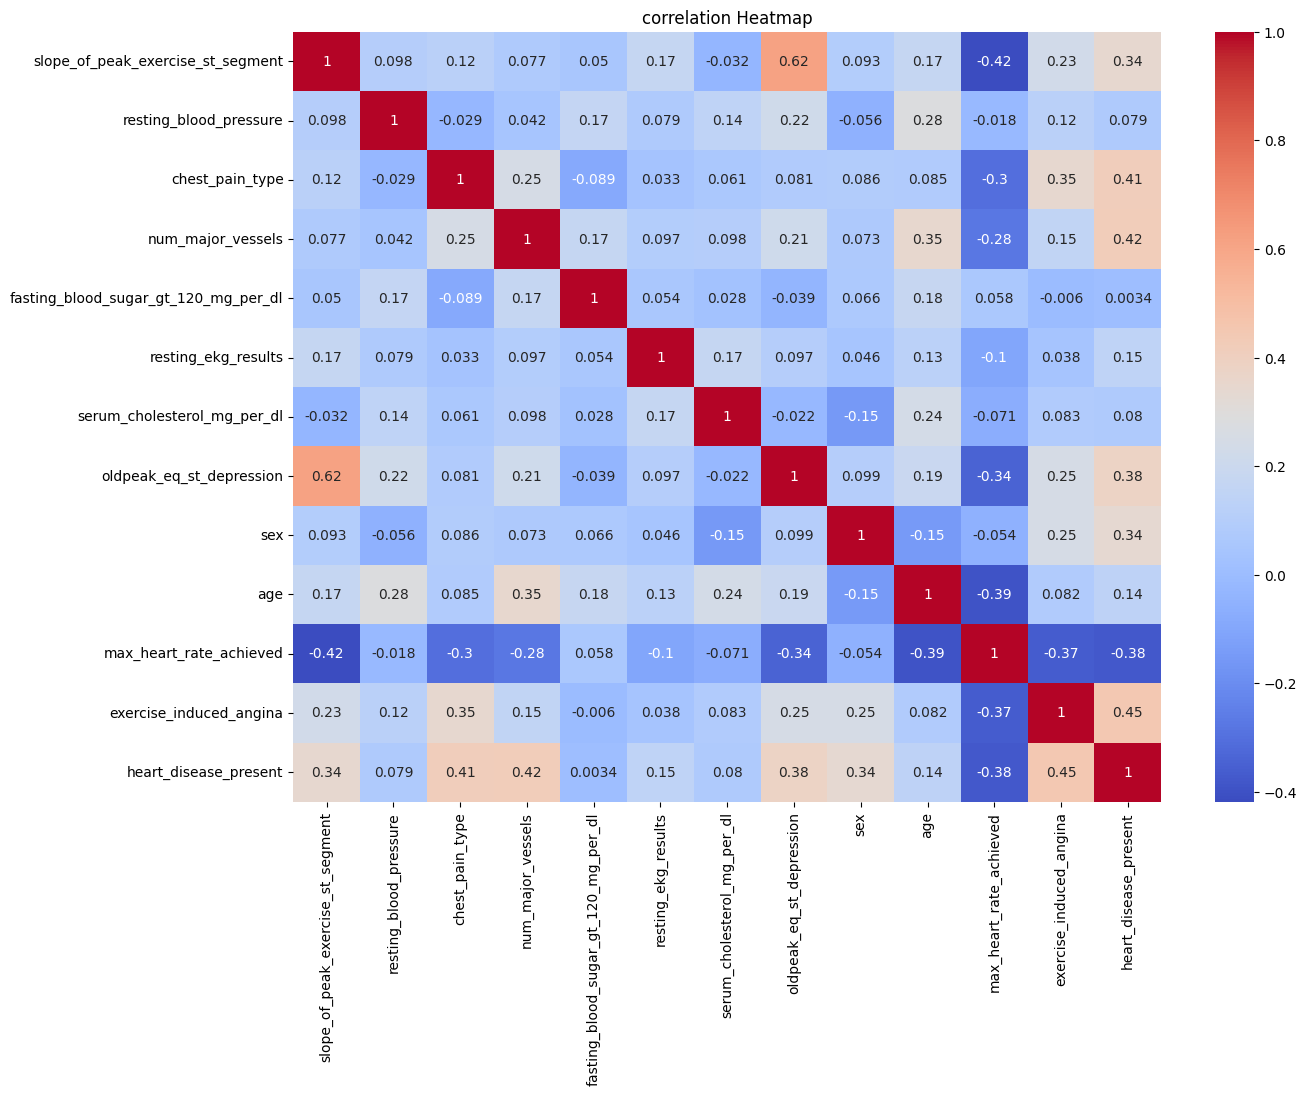

In [13]:
# Correlation Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only= True),
            annot=True,
            cmap="coolwarm")
plt.title("correlation Heatmap")
plt.show()

# Insight:
- Correlation analysis identifies features strongly related to heart disease.
- Highly correlated features can improve prediction performance.

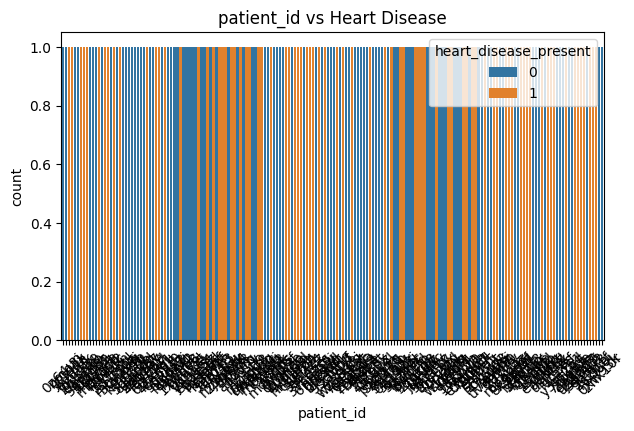

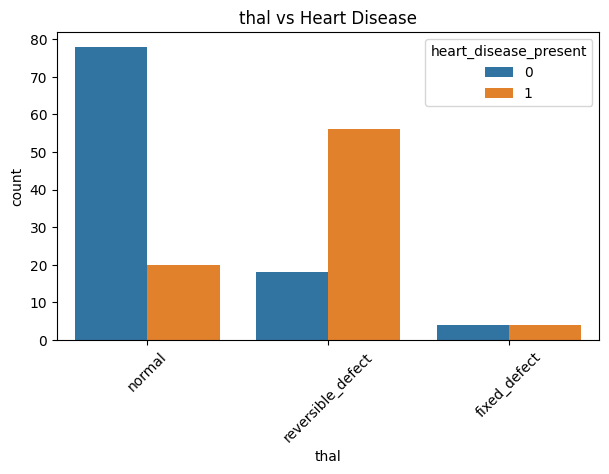

In [14]:
# Categorical Feature Analysis
cat_cols = df.select_dtypes(include= "object").columns
for col in cat_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col,
                  hue= "heart_disease_present",
                  data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Heart Disease")
    plt.show()
                  
    

# Insight:
- Categorical analysis helps understand how different groups
- impact heart disease risk.

In [15]:
# data cleaning 
# Remove Duplicates
df.drop_duplicates(inplace=True)
print("Duplicates Removed Successfully")

Duplicates Removed Successfully


In [16]:
# Missing Value Treatment
num_features = df.select_dtypes(include=np.number).columns
cat_features = df.select_dtypes(include='object').columns

# Numerical Features
for col in num_features:
    df[col] = df[col].fillna(df[col].median())   # ← changed
for col in cat_features:
    df[col] = df[col].fillna(df[col].mode()[0])  # ← changed
print("Missing Values After Treatment")
print(df.isnull().sum().sum())

Missing Values After Treatment
0


# Feature Engineering

In [17]:
# Age Group Feature
df['age_group'] = pd.cut(df['age'],
                         bins=[0, 40, 50, 60, 70, 120],
                         labels=['Below 40', '40-50', '51-60', '61-70', '71+'])
# Cholesterol per Age
df['chol_age_ratio'] = df['serum_cholesterol_mg_per_dl'] / df['age']
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present,age_group,chol_age_ratio
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0,40-50,6.844444
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0,51-60,3.962963
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1,71+,3.948052
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1,Below 40,5.575000
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0,51-60,4.576271


In [18]:
# Check class imbalance
print(df['heart_disease_present'].value_counts())
print(df['heart_disease_present'].value_counts(normalize=True))

heart_disease_present
0    100
1     80
Name: count, dtype: int64
heart_disease_present
0    0.555556
1    0.444444
Name: proportion, dtype: float64


# Insight:
- Feature engineering creates meaningful features that may improve model performance.

In [19]:
# Define Features and Target
X = df.drop(['patient_id', 'heart_disease_present'], axis=1)
y = df['heart_disease_present']

# One Hot Encoding

In [20]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,chol_age_ratio,thal_normal,thal_reversible_defect,age_group_40-50,age_group_51-60,age_group_61-70,age_group_71+
0,1,128,2,0,0,2,308,0.0,1,45,170,0,6.844444,True,False,True,False,False,False
1,2,110,3,0,0,0,214,1.6,0,54,158,0,3.962963,True,False,False,True,False,False
2,1,125,4,3,0,2,304,0.0,1,77,162,1,3.948052,True,False,False,False,False,True
3,1,152,4,0,0,0,223,0.0,1,40,181,0,5.575000,False,True,False,False,False,False
4,3,178,1,0,0,2,270,4.2,1,59,145,0,4.576271,False,True,False,True,False,False


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')


In [22]:
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42,stratify=y)
print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (144, 19)
Testing Shape : (36, 19)


# Feature Scaling

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_scaled, y_train = sm.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", pd.Series(y_train).value_counts())

After SMOTE: heart_disease_present
0    80
1    80
Name: count, dtype: int64


# Baseline Models

In [25]:
models = {
    
    'Logistic Regression': LogisticRegression(),
    
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    
    'Random Forest': RandomForestClassifier(random_state=42),
    
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    
    'XGBoost': XGBClassifier(eval_metric='logloss',
                             random_state=42)
}

# Model Training and Evaluation

In [26]:
results = []

for name, model in models.items():
    
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    
    results.append({
        
        'Model': name,
        
        'Accuracy': accuracy_score(y_test, y_pred),
        
        'Precision': precision_score(y_test, y_pred),
        
        'Recall': recall_score(y_test, y_pred),
        
        'F1 Score': f1_score(y_test, y_pred),
        
        'ROC AUC': roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(by='F1 Score',
                       ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,Gradient Boosting,0.888889,0.833333,0.9375,0.882353,0.928125
2,Random Forest,0.861111,0.789474,0.9375,0.857143,0.931250
0,Logistic Regression,0.805556,0.736842,0.8750,0.800000,0.931250
4,XGBoost,0.750000,0.666667,0.8750,0.756757,0.909375
1,Decision Tree,0.777778,0.750000,0.7500,0.750000,0.775000


# Hyperparameter Tuning

In [27]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    
    'n_estimators': [100,200,300],
    
    'max_depth': [5,10,15,None],
    
    'min_samples_split': [2,5,10],
    
    'min_samples_leaf': [1,2,4]
}

random_search = RandomizedSearchCV(
    
    estimator=rf,
    
    param_distributions=param_grid,
    
    n_iter=10,
    
    scoring='f1',
    
    cv=5,
    
    random_state=42,
    
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

best_rf = random_search.best_estimator_

print(random_search.best_params_)

{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


# Cross Validation

In [28]:
cv_scores = cross_val_score(
    
    best_rf,
    
    X_train_scaled,
    
    y_train,
    
    cv=5,
    
    scoring='f1'
)

print("CV Scores :", cv_scores)

print("Average CV Score :", cv_scores.mean())

CV Scores : [0.85714286 0.8125     0.75       0.8        0.94117647]
Average CV Score : 0.8321638655462186


# Final Predictions

In [29]:
y_pred = best_rf.predict(X_test_scaled)
y_prob = best_rf.predict_proba(X_test_scaled)[:,1]

In [30]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8333333333333334
Precision : 0.75
Recall : 0.9375
F1 Score : 0.8333333333333334
ROC AUC : 0.9421875000000001


# Classification Report

In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.75      0.83        20
           1       0.75      0.94      0.83        16

    accuracy                           0.83        36
   macro avg       0.84      0.84      0.83        36
weighted avg       0.85      0.83      0.83        36



# Confusion Matrix

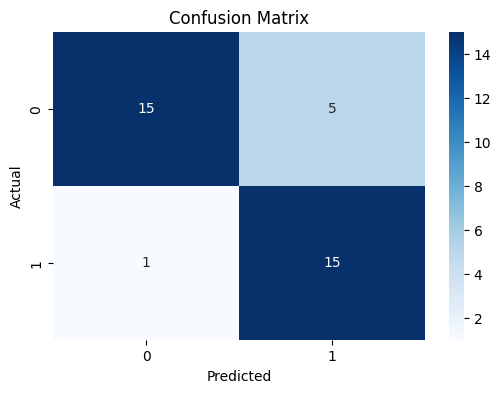

In [32]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ROC Curve

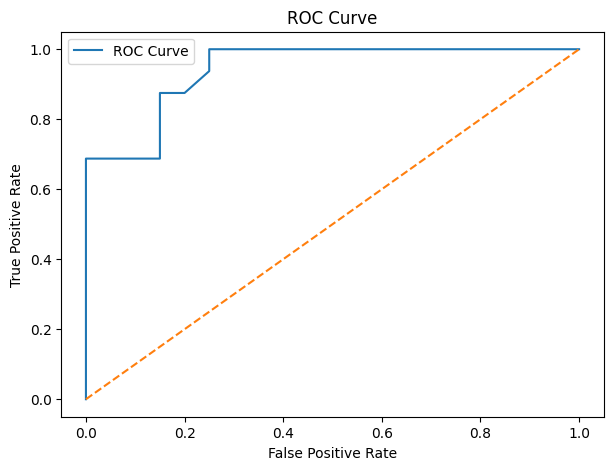

In [33]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label='ROC Curve')

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# Threshold Tuning

In [34]:
threshold = 0.4
y_pred_threshold = (y_prob >= threshold).astype(int)
print("F1 Score After Threshold Tuning")
print(f1_score(y_test, y_pred_threshold))

F1 Score After Threshold Tuning
0.8648648648648649


# Feature Importance

In [35]:
feature_importance = pd.DataFrame({
    
    'Feature': X.columns,
    
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    
    by='Importance',
    
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
13,thal_normal,0.102860
2,chest_pain_type,0.102632
9,age,0.089220
10,max_heart_rate_achieved,0.081066
14,thal_reversible_defect,0.080895
3,num_major_vessels,0.080197
6,serum_cholesterol_mg_per_dl,0.076380
7,oldpeak_eq_st_depression,0.065193
1,resting_blood_pressure,0.064526
11,exercise_induced_angina,0.057517


# Feature Importance Plot

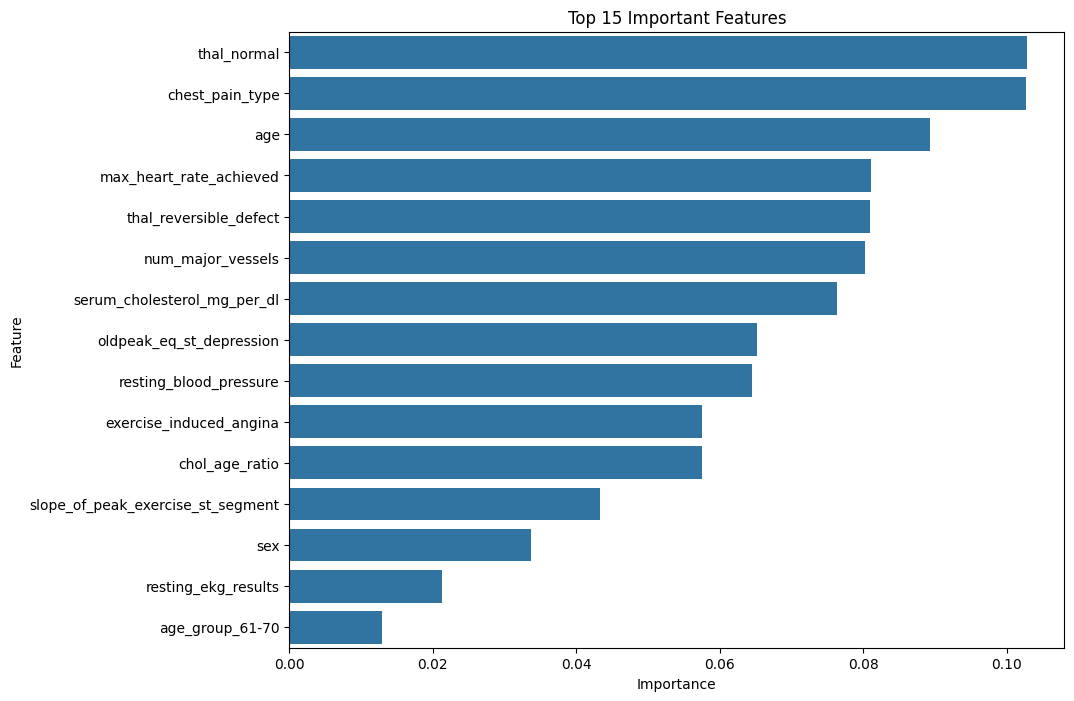

In [36]:
plt.figure(figsize=(10,8))

sns.barplot(x='Importance',
            y='Feature',
            data=feature_importance.head(15))

plt.title("Top 15 Important Features")

plt.show()

# SHAP Explainability

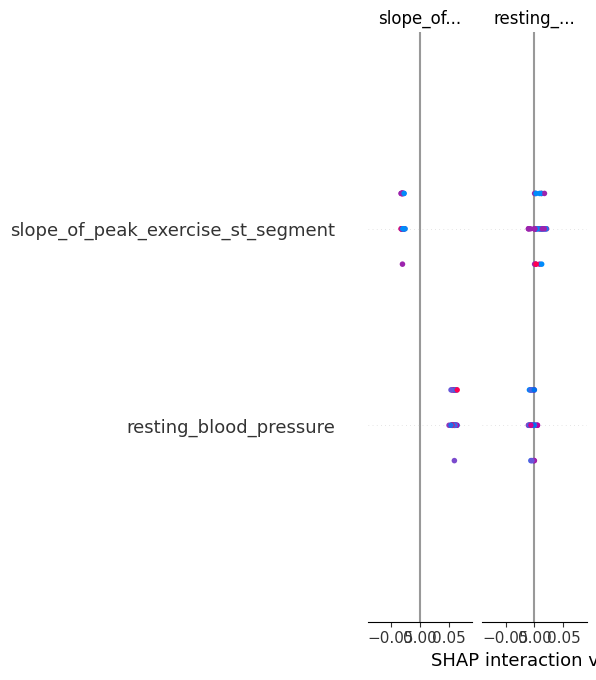

In [37]:
import shap

explainer = shap.TreeExplainer(best_rf)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

# Business Recommendations

1. Focus on patients with high cholesterol and abnormal ECG results.
2. Conduct regular screening for elderly patients.
3. Monitor exercise-induced angina carefully.
4. Deploy ML-based risk scoring systems in hospitals.
5. Increase awareness regarding cardiovascular diseases.

# Business Impact

- Early disease detection
- Reduced mortality rates
- Better healthcare planning
- Improved patient outcomes

# Challenges Faced

| Challenge | Solution |
|---|---|
| Missing Values | Median/Mode Imputation |
| Outliers | Visualization and Scaling |
| Model Overfitting | Cross Validation and Tuning |
| Feature Correlation | Correlation Analysis |
| Explainability | SHAP Explainability |

# Final Conclusion

- Multiple machine learning models were implemented successfully.
- Random Forest performed best after hyperparameter tuning.
- Important predictors included cholesterol, age, ECG results, and chest pain type.
- SHAP explainability improved transparency and interpretability.
- The model can help hospitals identify high-risk patients early.

# Future Improvements

- Implement LightGBM and CatBoost
- Use advanced feature selection techniques
- Deploy using Streamlit or Flask
- Integrate real-time hospital data

In [38]:
import joblib
import json

# Save model
joblib.dump(best_rf, 'model.pkl')

# Save scaler
joblib.dump(scaler, 'scaler.pkl')

# Save feature column names
with open('feature_cols.json', 'w') as f:
    json.dump(X.columns.tolist(), f)

print("✅ model.pkl saved")
print("✅ scaler.pkl saved")
print("✅ feature_cols.json saved")

✅ model.pkl saved
✅ scaler.pkl saved
✅ feature_cols.json saved
